# VII. Explainability (XAI) — Transformer Classifier

Notebook de explicabilidad del modelo **GLU-Transformer** entrenado sobre datos de interacción del OULAD.

**Estrategia dual:**
1. **Intrínseca** — Extracción de mapas de atención por capa/cabeza para entender el foco temporal del modelo.
2. **Agnóstica** — SHAP (KernelExplainer) para cuantificar la contribución de cada variable (secuencial + estática) a la predicción.
3. **Análisis de errores** — Inspección de los casos más difíciles para el modelo.

> **Split analizado**: Validación  
> **Objetivo**: generar evidencia accionable para intervención educativa temprana.

## 1) Setup, dependencias y configuración

In [1]:
!nvidia-smi


Thu Mar  5 20:42:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.52.01              Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080 ...    On  |   00000000:52:00.0  On |                  N/A |
| N/A   39C    P4             26W /  140W |    2579MiB /  16303MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import sys

# Insertar el root en sys.path para poder cargar config
sys.path.insert(0, '/workspace/TFM_education_ai_analytics')
from educational_ai_analytics.config import EXECUTION_DEVICE

# Adaptaciones para saltarnos la compilacion JIT pesada de la RTX 5080
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0 --tf_xla_enable_xla_devices=false"
os.environ["XLA_FLAGS"] = "--xla_gpu_enable_triton_gemm=false"
os.environ["CUDA_CACHE_DISABLE"] = "1"

if EXECUTION_DEVICE == "cpu":
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
    print("✅ Forzando ejecución en CPU para evitar XLA overheads de la RTX 5080.")
else:
    print("⚠️ Ejecutando en GPU. Podrían producirse tirones por el JIT compilation.")


✅ Forzando ejecución en CPU para evitar XLA overheads de la RTX 5080.


In [3]:
import os
import sys
import json
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, balanced_accuracy_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)

# ─── Estilo visual ────────────────────────────────────────────────────────────
DARK_BG   = '#0F1117'
PANEL_BG  = '#1A1D27'
GRID_CLR  = '#2A2D3A'
TEXT_CLR  = '#E8EAED'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   PANEL_BG,
    'text.color':       TEXT_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'axes.edgecolor':   GRID_CLR,
    'grid.color':       GRID_CLR,
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'font.sans-serif':  ['DejaVu Sans'],
})
np.set_printoptions(suppress=True, precision=4)

# ─── Proyecto ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('/workspace/TFM_education_ai_analytics')
os.chdir(PROJECT_ROOT)

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL EXPERIMENTO  (✏️ editar aquí)
# ═══════════════════════════════════════════════════════════════════════════════
UPTO_WEEK    = 5
SPLIT        = 'validation'
NUM_CLASSES  = 2
BINARY_MODE  = 'paper'          # paper | original | success_vs_risk
WITH_STATIC  = True

# Derivar rutas automáticamente
TARGET_TAG   = f'{NUM_CLASSES}clases_{BINARY_MODE}' if NUM_CLASSES == 2 else f'{NUM_CLASSES}clases'
DATA_DIR     = PROJECT_ROOT / 'data' / '6_transformer_features'
MODEL_PATH   = PROJECT_ROOT / 'models' / 'transformers' / f'transformer_uptoW{UPTO_WEEK}_{TARGET_TAG}.keras'
HISTORY_PATH = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{UPTO_WEEK}' / f'experiments_history_{TARGET_TAG}.json'
REPORT_DIR   = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{UPTO_WEEK}'
HARDEST_CSV  = REPORT_DIR / f'hardest_val_examples_uptoW{UPTO_WEEK}_{TARGET_TAG}.csv'

print(f'Configuración:')
print(f'  Semana          : {UPTO_WEEK}')
print(f'  Split           : {SPLIT}')
print(f'  Clases          : {NUM_CLASSES} ({BINARY_MODE})')
print(f'  Con estáticas   : {WITH_STATIC}')
print(f'  Modelo          : {MODEL_PATH.name} (existe: {MODEL_PATH.exists()})')
print(f'  Historial       : {HISTORY_PATH.name} (existe: {HISTORY_PATH.exists()})')
print(f'  Hardest CSV     : {HARDEST_CSV.name} (existe: {HARDEST_CSV.exists()})')
print(f'  TensorFlow      : {tf.__version__}')

Configuración:
  Semana          : 5
  Split           : validation
  Clases          : 2 (paper)
  Con estáticas   : True
  Modelo          : transformer_uptoW5_2clases_paper.keras (existe: True)
  Historial       : experiments_history_2clases_paper.json (existe: True)
  Hardest CSV     : hardest_val_examples_uptoW5_2clases_paper.csv (existe: True)
  TensorFlow      : 2.20.0


## 2) Carga de datos, modelo y utilidades

In [4]:
# ─── Importar la arquitectura del Transformer ─────────────────────────────────
mod_path = PROJECT_ROOT / 'educational_ai_analytics' / '2_modeling' / 'transformers' / 'transformer_GLU_classifier.py'
spec = importlib.util.spec_from_file_location('transformer_GLU_classifier', mod_path)
tg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tg)

GLUTransformerClassifier = tg.GLUTransformerClassifier
TransformerEncoderBlock  = tg.TransformerEncoderBlock
GLULayer                 = tg.GLULayer


# ─── Funciones auxiliares ──────────────────────────────────────────────────────
def load_npz_split(split: str, upto_week: int, with_static: bool = True):
    fp = DATA_DIR / split / f'transformer_uptoW{upto_week}.npz'
    d  = np.load(fp, allow_pickle=True)

    X_seq         = d['X_seq'].astype(np.float32)
    mask_pad      = (d['mask_pad'] if 'mask_pad' in d.files else d['mask']).astype(np.int32)
    mask_activity = (d['mask_activity'] if 'mask_activity' in d.files else mask_pad).astype(np.int32)
    y             = d['y'].astype(np.int64)
    ids           = d['ids'].astype(str)

    X_static = d['X_static'].astype(np.float32) if with_static else None

    static_feature_names = d['static_feature_names'] if 'static_feature_names' in d.files else np.array([], dtype=object)
    static_feature_sources = d['static_feature_sources'] if 'static_feature_sources' in d.files else np.array([], dtype=object)
    activities = d['activities'] if 'activities' in d.files else np.array([], dtype=object)

    return {
        'X_seq': X_seq, 'mask_pad': mask_pad, 'mask_activity': mask_activity,
        'y': y, 'ids': ids, 'X_static': X_static,
        'static_feature_names': static_feature_names,
        'static_feature_sources': static_feature_sources,
        'activities': activities,
    }


def filter_classes_binary(payload, binary_mode: str):
    """Aplica el mismo filtro de clases que train_transformer.py."""
    y = payload['y']

    if binary_mode == 'paper':
        # Paper: Pass/Dist (y>=2) -> 0, Withdrawn (y==0) -> 1; Fail (y==1) se descarta
        keep = y != 1
        y_bin = np.where(y[keep] == 0, 1, 0).astype(np.int64)
    elif binary_mode == 'original':
        # Original: same but keep Fail(0)->1, remove Withdrawn(1)
        keep = y != 0
        y_kept = y[keep]
        y_bin = np.where(y_kept == 1, 1, 0).astype(np.int64)
    elif binary_mode == 'success_vs_risk':
        # Success vs Risk: Pass/Dist (>=2) -> 0, Fail/Withdrawn (0,1) -> 1
        keep = np.ones(len(y), dtype=bool)
        y_bin = np.where(y < 2, 1, 0).astype(np.int64)
    else:
        raise ValueError(f'binary_mode desconocido: {binary_mode}')

    result = {}
    for k, v in payload.items():
        if isinstance(v, np.ndarray) and v.shape[0] == len(y):
            result[k] = v[keep]
        else:
            result[k] = v
    result['y'] = y_bin
    return result


def load_model_from_history(model_path, history_path, upto_week, x_seq_sample, x_static_sample):
    """Carga robusta: reconstruye arquitectura desde historial + carga pesos."""
    hist = json.loads(history_path.read_text(encoding='utf-8'))
    candidates = [r for r in hist if int(r.get('hyperparameters', {}).get('upto_week', -1)) == int(upto_week)]
    if not candidates:
        raise ValueError(f'No hay entradas en historial para upto_week={upto_week}')
    hp = candidates[-1]['hyperparameters']

    model = GLUTransformerClassifier(
        latent_d=int(hp.get('latent_d', 256)),
        num_heads=int(hp.get('num_heads', 8)),
        ff_dim=int(hp.get('ff_dim', 128)),
        dropout=float(hp.get('dropout', 0.3)),
        num_classes=int(hp.get('num_classes', NUM_CLASSES)),
        num_layers=int(hp.get('num_layers', 2)),
        max_len=int(x_seq_sample.shape[1]),
        with_static_features=bool(hp.get('with_static', True)),
        static_hidden=tuple(hp.get('static_hidden', [64, 32])),
        head_hidden=tuple(hp.get('head_hidden', [256, 128])),
    )

    # Forward pass de calentamiento para construir pesos
    seq = x_seq_sample[:2].astype(np.float32)
    m = np.ones(seq.shape[:2], dtype=np.int32)
    inputs = [seq, m, m]
    if bool(hp.get('with_static', True)) and x_static_sample is not None:
        inputs.append(x_static_sample[:2].astype(np.float32))
    _ = model(inputs, training=False)

    model.load_weights(model_path)
    return model, hp


# ─── Cargar datos ─────────────────────────────────────────────────────────────
payload_raw = load_npz_split(SPLIT, UPTO_WEEK, with_static=WITH_STATIC)

if NUM_CLASSES == 2:
    payload = filter_classes_binary(payload_raw, BINARY_MODE)
else:
    payload = payload_raw  # 3 o 4 clases: sin filtro

X_seq         = payload['X_seq']
mask_pad      = payload['mask_pad']
mask_activity = payload['mask_activity']
X_static      = payload['X_static']
y             = payload['y']
ids           = payload['ids']
activities    = payload['activities']
static_names  = payload['static_feature_names']

N, W, F = X_seq.shape
print(f'\n📊 Datos cargados ({SPLIT}):')
print(f'  X_seq:     {X_seq.shape}')
print(f'  X_static:  {X_static.shape if X_static is not None else "N/A"}')
print(f'  y:         {y.shape} | distribución: {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'  IDs:       {ids.shape}')
print(f'  Semanas:   {W} | Features seq: {F} | Features estáticas: {X_static.shape[1] if X_static is not None else 0}')
print(f'  Actividades: {list(activities.astype(str)[:10])}...'  if len(activities) > 10 else f'  Actividades: {list(activities.astype(str))}')

# ─── Cargar modelo ─────────────────────────────────────────────────────────────
model, hp_loaded = load_model_from_history(
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    upto_week=UPTO_WEEK,
    x_seq_sample=X_seq,
    x_static_sample=X_static,
)
print(f'\n✅ Modelo cargado: {MODEL_PATH.name}')
print(f'  Hiperparámetros: latent_d={hp_loaded.get("latent_d")}, num_heads={hp_loaded.get("num_heads")}, '
      f'ff_dim={hp_loaded.get("ff_dim")}, num_layers={hp_loaded.get("num_layers")}, dropout={hp_loaded.get("dropout")}')

# ─── Predicción rápida para verificar alineación ──────────────────────────────
inputs_val = [X_seq, mask_pad.astype(np.int32), mask_activity.astype(np.int32)]
if X_static is not None:
    inputs_val.append(X_static)

probs = model.predict(inputs_val, verbose=0)
y_pred = np.argmax(probs, axis=1)

bal_acc = balanced_accuracy_score(y, y_pred)
print(f'\n📈 Verificación rápida sobre {SPLIT}:')
print(f'  Balanced Accuracy: {bal_acc:.4f}')
print(f'  Confusion Matrix:\n{confusion_matrix(y, y_pred)}')
print(f'\n{classification_report(y, y_pred, digits=4)}')

if NUM_CLASSES == 2:
    auc_score = roc_auc_score(y, probs[:, 1])
    print(f'  AUC: {auc_score:.4f}')


📊 Datos cargados (validation):
  X_seq:     (3252, 5, 20)
  X_static:  (3252, 65)
  y:         (3252,) | distribución: {0: 2266, 1: 986}
  IDs:       (3252,)
  Semanas:   5 | Features seq: 20 | Features estáticas: 65
  Actividades: ['dataplus', 'dualpane', 'externalquiz', 'folder', 'forumng', 'glossary', 'homepage', 'htmlactivity', 'oucollaborate', 'oucontent']...

✅ Modelo cargado: transformer_uptoW5_2clases_paper.keras
  Hiperparámetros: latent_d=256, num_heads=8, ff_dim=128, num_layers=2, dropout=0.3

📈 Verificación rápida sobre validation:
  Balanced Accuracy: 0.7681
  Confusion Matrix:
[[1909  357]
 [ 302  684]]

              precision    recall  f1-score   support

           0     0.8634    0.8425    0.8528      2266
           1     0.6571    0.6937    0.6749       986

    accuracy                         0.7974      3252
   macro avg     0.7602    0.7681    0.7638      3252
weighted avg     0.8008    0.7974    0.7989      3252

  AUC: 0.8302


In [5]:
# Celda nueva: Saliency temporal (intrínseca)
import tensorflow as tf
import numpy as np

# Submuestra para no reventar memoria
n_explain = min(256, len(X_seq))
x_seq_e = tf.convert_to_tensor(X_seq[:n_explain])
m_pad_e = tf.convert_to_tensor(mask_pad[:n_explain].astype(np.int32))
m_act_e = tf.convert_to_tensor(mask_activity[:n_explain].astype(np.int32))
inputs_e = [x_seq_e, m_pad_e, m_act_e]
if X_static is not None:
    x_static_e = tf.convert_to_tensor(X_static[:n_explain])
    inputs_e.append(x_static_e)

with tf.GradientTape() as tape:
    tape.watch(x_seq_e)
    p = model(inputs_e, training=False)
    # prob de clase positiva en binario; en multi, usa clase predicha
    if NUM_CLASSES == 2:
        target = p[:, 1]
    else:
        cls = tf.argmax(p, axis=1)
        target = tf.gather(p, cls, axis=1, batch_dims=1)

grads = tape.gradient(target, x_seq_e).numpy()              # [N, W, F]
saliency_wf = np.mean(np.abs(grads), axis=0)                # [W, F]
saliency_w = saliency_wf.mean(axis=1)                       # [W]

print("Saliency temporal por semana:", saliency_w.round(4))

Saliency temporal por semana: [0.0026 0.002  0.0013 0.0034 0.0039]


In [7]:
# Celda nueva: SHAP KernelExplainer (agnóstico)
import shap
import numpy as np

N = len(X_seq)
W, F = X_seq.shape[1], X_seq.shape[2]
S = 0 if X_static is None else X_static.shape[1]

def pack_flat(x_seq, x_static=None):
    x = x_seq.reshape(len(x_seq), W * F)
    if x_static is not None:
        x = np.concatenate([x, x_static], axis=1)
    return x

def unpack_flat(x_flat):
    x_flat = np.asarray(x_flat)
    x_seq_u = x_flat[:, :W * F].reshape(-1, W, F).astype(np.float32)
    if S > 0:
        x_static_u = x_flat[:, W * F:].astype(np.float32)
    else:
        x_static_u = None
    return x_seq_u, x_static_u

def build_masks_from_seq(x_seq_u):
    # Para muestras sintéticas de SHAP no podemos reutilizar máscaras globales;
    # las derivamos por fila para mantener cardinalidad consistente.
    m_activity = (np.abs(x_seq_u).sum(axis=2) > 0).astype(np.int32)
    m_pad = np.ones_like(m_activity, dtype=np.int32)
    return m_pad, m_activity

def f_predict(x_flat):
    xs, xst = unpack_flat(x_flat)
    m_pad_s, m_act_s = build_masks_from_seq(xs)
    ins = [xs, m_pad_s, m_act_s]
    if xst is not None:
        ins.append(xst)
    p = model.predict(ins, verbose=0)
    return p[:, 1] if NUM_CLASSES == 2 else np.max(p, axis=1)

X_flat = pack_flat(X_seq, X_static)
bg_idx = np.random.choice(N, size=min(100, N), replace=False)
ex_idx = np.random.choice(N, size=min(80, N), replace=False)

explainer = shap.KernelExplainer(f_predict, X_flat[bg_idx])
shap_values = explainer.shap_values(X_flat[ex_idx], nsamples=200)

print('SHAP listo:', np.array(shap_values).shape)

100%|██████████| 80/80 [03:15<00:00,  2.44s/it]

SHAP listo: (80, 165)


Top 15 features secuenciales:


,feature,mean_abs_shap
18,subpage,0.000619
2,externalquiz,0.000602
14,quiz,0.000529
6,homepage,0.000504
9,oucontent,0.000461
11,ouwiki,0.000393
1,dualpane,0.000342
0,dataplus,0.000293
19,url,0.000288
5,glossary,0.000280


Top 15 features estáticas:


,feature,mean_abs_shap
11,api_index,0.030169
12,avg_score,0.024126
39,last_week_clicks_weighted,0.009892
36,highest_education,0.009222
40,late_ratio,0.006066
37,imd_band,0.004488
64,weeks_since_last_submission,0.003513
63,weeks_since_last_activity,0.002883
57,studied_credits,0.001726
58,submission_count,0.001689


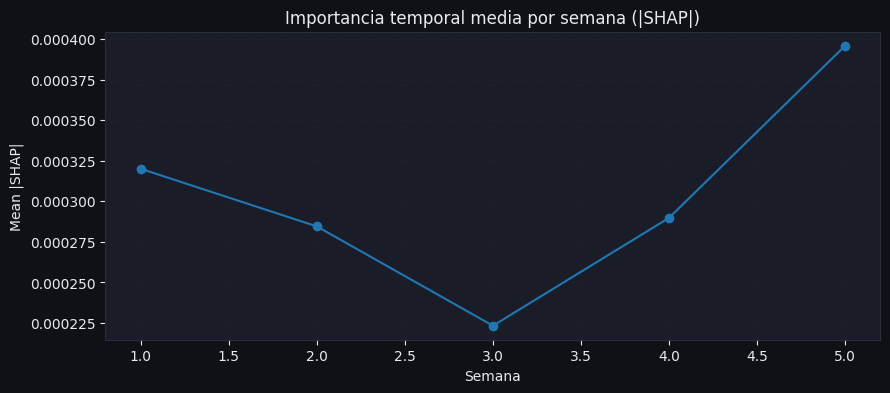

In [8]:
# 10) Resumen global de SHAP (importancia media |SHAP|)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Normalizar salida de SHAP (depende de versión/tipo de problema)
sv = shap_values
if isinstance(sv, list):
    # En binario, algunas versiones devuelven [clase0, clase1]
    sv = sv[1] if (NUM_CLASSES == 2 and len(sv) > 1) else sv[0]

sv = np.asarray(sv)
if sv.ndim == 3 and sv.shape[-1] == 1:
    sv = sv[..., 0]

# 2) Separar parte secuencial y estática
seq_cols = W * F
static_cols = S
assert sv.shape[1] == seq_cols + static_cols, (
    f"Columnas SHAP inesperadas: {sv.shape[1]} vs {seq_cols + static_cols}"
)

sv_seq = sv[:, :seq_cols].reshape(-1, W, F)   # [N, W, F]
imp_wf = np.abs(sv_seq).mean(axis=0)          # [W, F]
imp_week = imp_wf.mean(axis=1)                # [W]
imp_seq_feat = imp_wf.mean(axis=0)            # [F]

# Nombres de features secuenciales
if len(activities) == F:
    seq_feature_names = [str(a) for a in activities]
else:
    seq_feature_names = [f"seq_f{i}" for i in range(F)]

# 3) Top secuenciales
df_seq = pd.DataFrame({
    "feature": seq_feature_names,
    "mean_abs_shap": imp_seq_feat
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 features secuenciales:")
display(df_seq.head(15))

# 4) Top estáticas (si existen)
if S > 0:
    static_names_safe = [str(s) for s in static_names] if len(static_names) == S else [f"static_f{i}" for i in range(S)]
    imp_static = np.abs(sv[:, seq_cols:]).mean(axis=0)
    df_static = pd.DataFrame({
        "feature": static_names_safe,
        "mean_abs_shap": imp_static
    }).sort_values("mean_abs_shap", ascending=False)

    print("Top 15 features estáticas:")
    display(df_static.head(15))

# 5) Importancia temporal por semana
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, W + 1), imp_week, marker='o')
plt.title("Importancia temporal media por semana (|SHAP|)")
plt.xlabel("Semana")
plt.ylabel("Mean |SHAP|")
plt.grid(True, alpha=0.3)
plt.show()

Capas de atencion capturadas: 2
Shape por capa [B, H, W, W]: [(128, 8, 5, 5), (128, 8, 5, 5)]


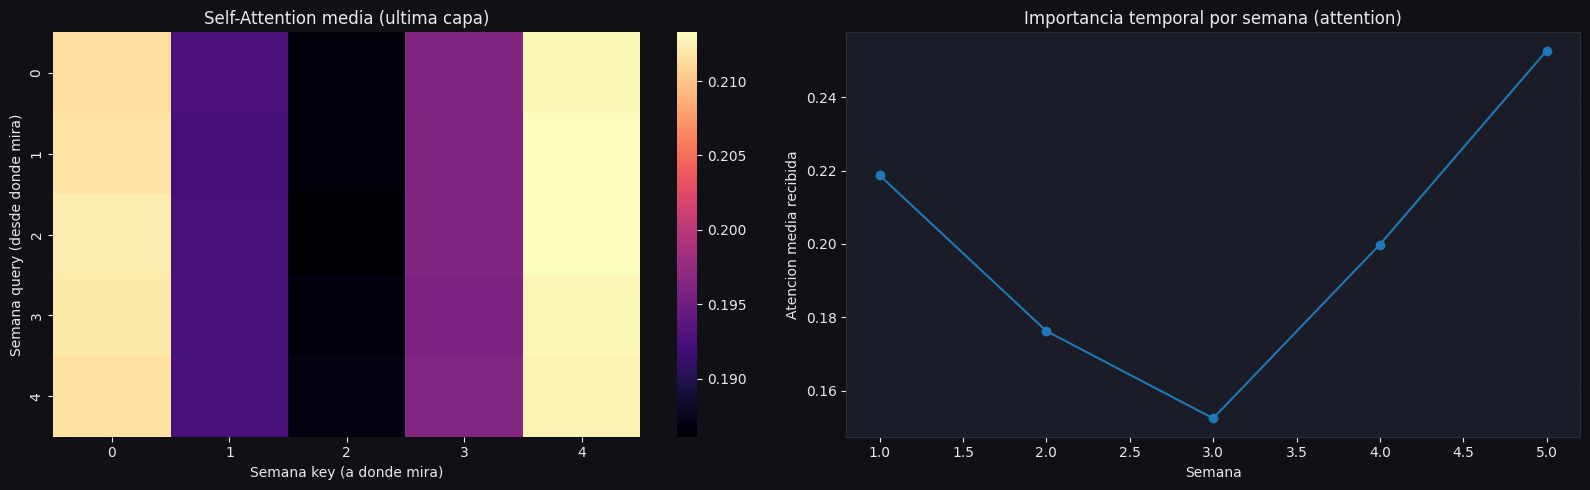

Top semanas por atencion media:


,week,attention_received
4,5,0.252676
0,1,0.218716
3,4,0.199854
1,2,0.176275
2,3,0.152479


In [9]:
# 11) Attention Maps intrinsecos (self-attention por capa/cabeza)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Submuestra para explicabilidad
n_attn = min(128, len(X_seq))
x_seq_a = tf.convert_to_tensor(X_seq[:n_attn], dtype=tf.float32)
seq_mask_a = tf.convert_to_tensor(mask_pad[:n_attn].astype(np.int32))
act_mask_a = tf.convert_to_tensor(mask_activity[:n_attn].astype(np.int32))

if X_static is not None:
    x_static_a = tf.convert_to_tensor(X_static[:n_attn], dtype=tf.float32)
else:
    x_static_a = None

# ---- Forward manual del backbone para capturar attention_scores ----
x = model.input_proj(x_seq_a)

if getattr(model, "with_static_features", False) and (x_static_a is not None):
    x_static_emb = model.static_block(x_static_a, training=False)          # (B, D)
    x_static_t = tf.expand_dims(x_static_emb, axis=1)                      # (B, 1, D)
    x_static_t = tf.broadcast_to(x_static_t, tf.shape(x))                  # (B, W, D)
    fusion_in = tf.concat([x, x_static_t], axis=-1)                        # (B, W, 2D)
    gate = model.fusion_gate(fusion_in)                                    # (B, W, D)
    x = (1.0 - gate) * x + gate * x_static_t

x = model.in_drop(x, training=False)

attn_layers = []
for enc in model.encoders:
    attn_mask = enc.make_attn_mask(seq_mask_a)  # (B, W, W)

    # Bloque attention (como en call), pero devolviendo scores
    h = enc.norm_attn(x)
    attn_out, attn_scores = enc.mha(
        h, h, h,
        attention_mask=attn_mask,
        return_attention_scores=True,
        training=False,
    )
    attn_out = enc.drop_attn(attn_out, training=False)
    x = x + attn_out

    # Bloque FFN
    h2 = enc.norm_ffn(x)
    ffn = enc.ffn_glu(h2)
    ffn = enc.ffn_out(ffn)
    ffn = enc.drop_ffn(ffn, training=False)
    x = x + ffn

    a = attn_scores.numpy()
    # Esperado: (B, H, W, W). Si viene (B, W, W), anadimos eje de heads.
    if a.ndim == 3:
        a = a[:, None, :, :]
    attn_layers.append(a)

print(f"Capas de atencion capturadas: {len(attn_layers)}")
print("Shape por capa [B, H, W, W]:", [a.shape for a in attn_layers])

# ---- Agregaciones ----
# Matriz (W, W) por capa: promedio en batch + heads
attn_mean_by_layer = [a.mean(axis=(0, 1)) for a in attn_layers]

# Importancia temporal por semana (cuanta atencion recibe cada semana-key)
# promedio sobre: capas, batch, heads, query
attn_all = np.stack(attn_layers, axis=0)                  # (L, B, H, W, W)
attn_week_importance = attn_all.mean(axis=(0, 1, 2, 3))   # (W,)

# ---- Visualizaciones ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(attn_mean_by_layer[-1], cmap="magma", ax=axes[0])
axes[0].set_title("Self-Attention media (ultima capa)")
axes[0].set_xlabel("Semana key (a donde mira)")
axes[0].set_ylabel("Semana query (desde donde mira)")

axes[1].plot(np.arange(1, W + 1), attn_week_importance, marker="o")
axes[1].set_title("Importancia temporal por semana (attention)")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("Atencion media recibida")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla para reporte
attn_df = pd.DataFrame({
    "week": np.arange(1, W + 1),
    "attention_received": attn_week_importance
}).sort_values("attention_received", ascending=False)

print("Top semanas por atencion media:")
display(attn_df.head(10))

In [10]:
# 12) Marco de explicaciones accionables (XAI -> accion docente)
import numpy as np
import pandas as pd

# ---------- Utilidades ----------
def _normalize_shap_output(shap_values_obj, num_classes=2):
    sv = shap_values_obj
    if isinstance(sv, list):
        sv = sv[1] if (num_classes == 2 and len(sv) > 1) else sv[0]
    sv = np.asarray(sv)
    if sv.ndim == 3 and sv.shape[-1] == 1:
        sv = sv[..., 0]
    return sv


def _risk_band(p):
    if p >= 0.75:
        return "alto"
    if p >= 0.50:
        return "medio"
    return "bajo"


def _recommend_action(risk_prob, top_feats, attn_weeks):
    fset = set(top_feats)
    attn_txt = ", ".join([f"S{w}" for w in attn_weeks[:3]]) if len(attn_weeks) else "S?"

    if {"submission_count", "weeks_since_last_submission", "late_ratio"} & fset:
        return (
            "Plan de reenganche 7 dias: recordatorio activo, micro-entrega y tutoria breve.",
            "KPI: +1 entrega esta semana, reduccion de retraso y riesgo en proxima inferencia."
        )

    if {"avg_score", "score_slope", "api_index"} & fset:
        return (
            "Refuerzo academico focalizado: feedback de errores + actividad de recuperacion guiada.",
            "KPI: mejora de avg_score y api_index en 1-2 semanas."
        )

    if {"clicks_questionnaire", "clicks_externalquiz", "clicks_dualpane"} & fset:
        return (
            "Intervencion de participacion: secuencia corta de actividad evaluable en " + attn_txt + ".",
            "KPI: aumento de interacciones clave y continuidad semanal."
        )

    if risk_prob >= 0.75:
        return (
            "Seguimiento proactivo: contacto individual y plan semanal con hitos.",
            "KPI: mantener actividad semanal y bajar probabilidad de riesgo."
        )

    return (
        "Mantener seguimiento ligero con mensaje preventivo y objetivo semanal.",
        "KPI: estabilidad de participacion y rendimiento."
    )


# ---------- Entradas necesarias ----------
required_vars = ["shap_values", "ex_idx", "ids", "probs", "attn_week_importance", "W", "F", "S"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Faltan variables para esta celda: {missing}. Ejecuta antes celdas SHAP y Attention.")

sv = _normalize_shap_output(shap_values, num_classes=NUM_CLASSES)
seq_cols = W * F
all_cols = seq_cols + S

if sv.shape[1] != all_cols:
    raise RuntimeError(f"Shape SHAP inesperado: {sv.shape}. Esperado segunda dimension={all_cols}.")

# Nombres de features (secuenciales + estaticas)
if len(activities) == F:
    seq_feature_names = [str(a) for a in activities]
else:
    seq_feature_names = [f"seq_f{i}" for i in range(F)]

if S > 0:
    static_names_safe = [str(s) for s in static_names] if len(static_names) == S else [f"static_f{i}" for i in range(S)]
else:
    static_names_safe = []

feature_names = [f"seq::{n}" for n in seq_feature_names for _ in [0]]
# Expandimos seq names por semana para mapear W*F columnas
feature_names = [f"w{w+1}_{seq_feature_names[f]}" for w in range(W) for f in range(F)] + static_names_safe

# Semanas con mayor atencion global
top_attn_weeks = (np.argsort(attn_week_importance)[::-1] + 1).tolist()

# ---------- Construir tabla accionable por estudiante explicado en SHAP ----------
rows = []
for i, idx in enumerate(ex_idx):
    student_id = str(ids[idx])
    risk_prob = float(probs[idx, 1]) if NUM_CLASSES == 2 else float(np.max(probs[idx]))
    pred_class = int(np.argmax(probs[idx]))

    contrib = sv[i]  # contribuciones de este estudiante
    # Top features que empujan a riesgo (contrib positiva para clase riesgo en binario)
    top_pos_idx = np.argsort(contrib)[-5:][::-1]
    top_pos_pairs = [(feature_names[j], float(contrib[j])) for j in top_pos_idx]
    top_pos_features = [p[0] for p in top_pos_pairs]

    action, kpi = _recommend_action(risk_prob, top_pos_features, top_attn_weeks)

    rows.append({
        "student_id": student_id,
        "risk_prob": round(risk_prob, 4),
        "risk_band": _risk_band(risk_prob),
        "pred_class": pred_class,
        "top_shap_risk_features": "; ".join([f"{n} ({v:.3f})" for n, v in top_pos_pairs]),
        "attention_focus_weeks": ", ".join([f"S{w}" for w in top_attn_weeks[:3]]),
        "recommended_action": action,
        "kpi_followup": kpi,
    })

action_df = pd.DataFrame(rows).sort_values(["risk_prob"], ascending=False)

print("Vista previa de explicaciones accionables:")
display(action_df.head(20))

out_csv = REPORT_DIR / f"actionable_explanations_uptoW{UPTO_WEEK}_{TARGET_TAG}.csv"
action_df.to_csv(out_csv, index=False)
print(f"Guardado: {out_csv}")

Vista previa de explicaciones accionables:


,student_id,risk_prob,risk_band,pred_class,top_shap_risk_features,attention_focus_weeks,recommended_action,kpi_followup
70,678397_FFF_2014J,0.8251,alto,1,api_index (0.079); avg_score (0.042); w4_subpa...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
3,599429_CCC_2014J,0.8194,alto,1,api_index (0.063); avg_score (0.052); last_wee...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
16,482580_FFF_2013J,0.8176,alto,1,avg_score (0.069); api_index (0.053); w5_ouwik...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
17,160720_FFF_2013J,0.8145,alto,1,weeks_since_last_activity (0.054); avg_score (...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
73,111548_DDD_2013J,0.7987,alto,1,avg_score (0.065); api_index (0.061); w5_exter...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
21,627520_CCC_2014B,0.7934,alto,1,avg_score (0.072); api_index (0.070); imd_band...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
13,1626021_BBB_2014B,0.7795,alto,1,avg_score (0.084); api_index (0.050); last_wee...,"S5, S1, S4",Plan de reenganche 7 dias: recordatorio activo...,"KPI: +1 entrega esta semana, reduccion de retr..."
44,537654_CCC_2014J,0.7779,alto,1,api_index (0.062); avg_score (0.058); last_wee...,"S5, S1, S4",Plan de reenganche 7 dias: recordatorio activo...,"KPI: +1 entrega esta semana, reduccion de retr..."
40,446746_FFF_2013J,0.7013,medio,1,avg_score (0.047); api_index (0.043); highest_...,"S5, S1, S4",Refuerzo academico focalizado: feedback de err...,KPI: mejora de avg_score y api_index en 1-2 se...
66,1439723_CCC_2014J,0.6895,medio,1,api_index (0.060); avg_score (0.040); late_rat...,"S5, S1, S4",Plan de reenganche 7 dias: recordatorio activo...,"KPI: +1 entrega esta semana, reduccion de retr..."


Guardado: /workspace/TFM_education_ai_analytics/reports/transformer_training/week_5/actionable_explanations_uptoW5_2clases_paper.csv
